# Challenge 2 : Building an unsupervised optical character recognizer

## Project Introduction

This notebook is developed as part of the **Data Analytics and Artificial Intelligence** course at **Ca' Foscari University of Venice**.

student number : 909059

name and surname : Chiara Masi 

For this notebook I use documentation :

#### scikit-learn
- Guide clustering → [sklearn.cluster](https://scikit-learn.org/stable/modules/clustering.html)
- KMeans → [sklearn.cluster.KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
- AgglomerativeClustering → [sklearn.cluster.AgglomerativeClustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)
- load_digits → [sklearn.datasets.load_digits](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)

#### SciPy
- linear_sum_assignment (Hungarian) → [scipy.optimize.linear_sum_assignment](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html)
- linkage / dendrogram → [scipy.cluster.hierarchy.linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html)

### Context

The objective of this challenge is to build an unsupervised optical character recognizer (OCR) using a classic handwritten digits dataset, called National Institute of Standards and Technology (NIST).


## 1. Import libraries

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn import datasets
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

%matplotlib inline

## 2. load dataset

The NIST datasets includes 1797 samples with 64 feature (8×8 grayscale images).

In [8]:
# Load dataset
digits = datasets.load_digits()

X      = digits.data    
y      = digits.target  # true labels
images = digits.images 

print(f'Feature matrix shape : {X.shape}')
print(f'Number of classes     : {len(np.unique(y))}  → {np.unique(y)}')
print(f'Samples per class     : {np.bincount(y)}')

Feature matrix shape : (1797, 64)
Number of classes     : 10  → [0 1 2 3 4 5 6 7 8 9]
Samples per class     : [178 182 177 183 181 182 181 179 174 180]


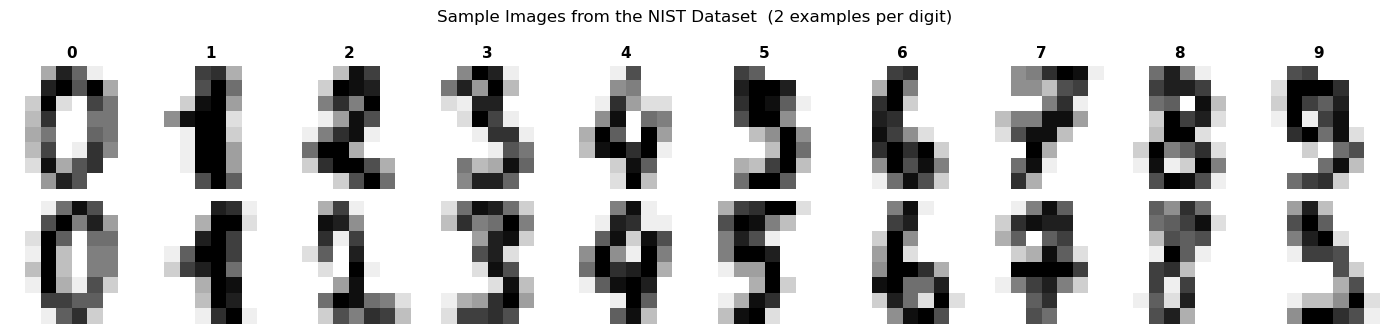

In [9]:
# Visualise 2 sample images per digit
fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
fig.suptitle('Sample Images from the NIST Dataset  (2 examples per digit)', fontsize=12)

for digit in range(10):
    indices = np.where(y == digit)[0]
    for row in range(2):
        axes[row, digit].imshow(images[indices[row]], cmap='gray_r', interpolation='nearest')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

The key step is to develop two clustering methods:K-Means and Agglomerative Clustering. We can explore different
hyperparameters and settings for these two unsupervised methods, while the recommendation
is to use 10 number of clusters as we have only 10 digits (0, 1, 2, 3, 4, 5, 6, 7, 8, and 9).

## 3. K-Means Clustering  (k = 10)

In [10]:
# Train K-Means 
kmeans = KMeans(
    n_clusters=10,   # one cluster per digit
    n_init=20,       
    random_state=42
)
km_labels = kmeans.fit_predict(X)

print(f'K-Means converged in {kmeans.n_iter_} iterations')
print(f'Final inertia (SSE)  : {kmeans.inertia_:.0f}')
print(f'Cluster sizes        : {np.bincount(km_labels)}')

K-Means converged in 18 iterations
Final inertia (SSE)  : 1165147
Cluster sizes        : [175 179 206  91 149 247 167 178 223 182]


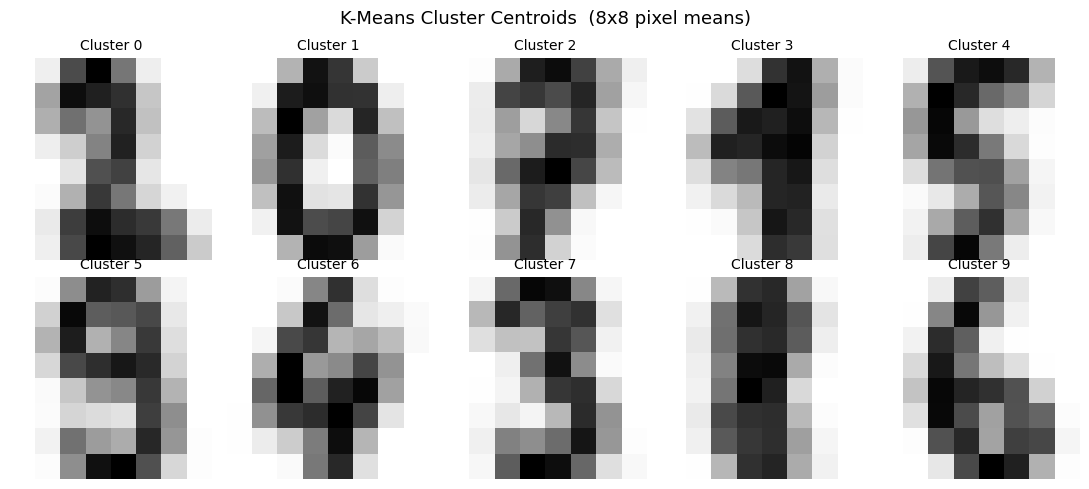

In [11]:
# Visualise 
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
fig.suptitle('K-Means Cluster Centroids  (8x8 pixel means)', fontsize=13)

for i, ax in enumerate(axes.flatten()):
    centroid = kmeans.cluster_centers_[i].reshape(8, 8)
    ax.imshow(centroid, cmap='gray_r', interpolation='nearest')
    ax.set_title(f'Cluster {i}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Agglomerative Clustering  (Ward linkage, k = 10)

In [12]:
agg = AgglomerativeClustering(
    n_clusters=10,
    linkage='ward'   # minimises SSE increase at each merge (same objective as K-Means)
)
agg_labels = agg.fit_predict(X)

print(f'Agglomerative cluster sizes : {np.bincount(agg_labels)}')

Agglomerative cluster sizes : [181 317 197 196 191 178 181 178  80  98]


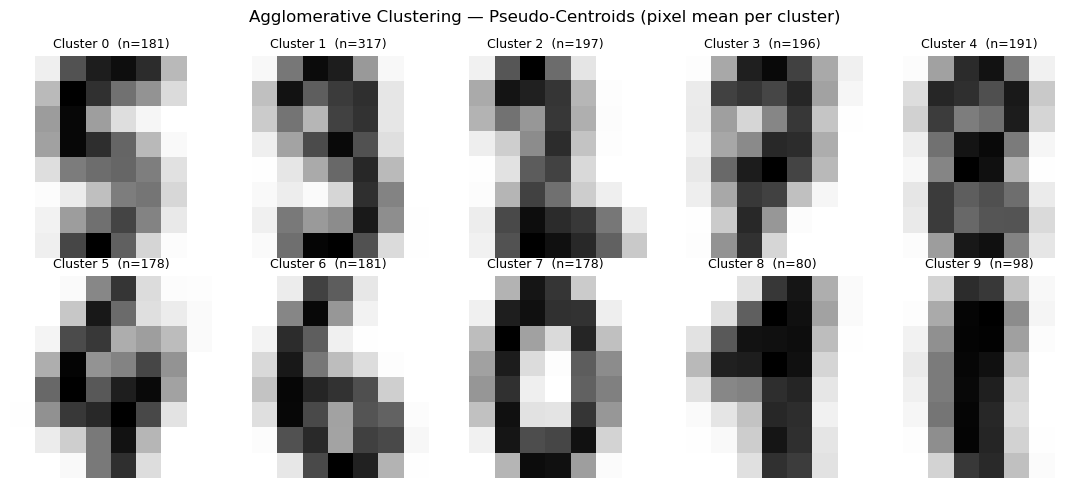

In [ ]:
agg_centroids = np.array([
    X[agg_labels == i].mean(axis=0)
    for i in range(10)
])

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
fig.suptitle('Agglomerative Clustering — Pseudo-Centroids (pixel mean per cluster)',
             fontsize=12)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(agg_centroids[i].reshape(8, 8), cmap='gray_r', interpolation='nearest')
    ax.set_title(f'Cluster {i}  (n={np.sum(agg_labels==i)})', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Optimal Cluster–Label Alignment  (Hungarian Algorithm)

Cluster IDs (0–9) are arbitrary and do not correspond to digit labels.  
We build a 10×10 cost matrix `C[i,j]` = number of samples in cluster `i` with true label `j`, then solve the assignment problem with the Hungarian algorithm to find the bijection `cluster_id → digit` that maximises accuracy.

In [14]:
def align_labels(true_labels, pred_labels, n_clusters=10):
    """
    Compute the optimal cluster→digit mapping using the Hungarian algorithm.
    Returns the re-labelled predictions and the mapping dictionary.
    """
    # Build cost matrix: C[i,j] = overlap between cluster i and digit j
    cost = np.zeros((n_clusters, n_clusters), dtype=int)
    for i in range(n_clusters):
        for j in range(n_clusters):
            cost[i, j] = np.sum((pred_labels == i) & (true_labels == j))

    # Solve assignment (maximise → negate cost)
    row_ind, col_ind = linear_sum_assignment(-cost)
    mapping  = {row_ind[k]: col_ind[k] for k in range(n_clusters)}
    aligned  = np.array([mapping[l] for l in pred_labels])
    return aligned, mapping, cost


km_aligned,  km_map,  km_cost  = align_labels(y, km_labels)
agg_aligned, agg_map, agg_cost = align_labels(y, agg_labels)

print('K-Means  cluster → digit mapping:', km_map)
print('Agg.Ward cluster → digit mapping:', agg_map)

K-Means  cluster → digit mapping: {np.int64(0): np.int64(2), np.int64(1): np.int64(0), np.int64(2): np.int64(7), np.int64(3): np.int64(1), np.int64(4): np.int64(5), np.int64(5): np.int64(9), np.int64(6): np.int64(4), np.int64(7): np.int64(3), np.int64(8): np.int64(8), np.int64(9): np.int64(6)}
Agg.Ward cluster → digit mapping: {np.int64(0): np.int64(5), np.int64(1): np.int64(3), np.int64(2): np.int64(2), np.int64(3): np.int64(7), np.int64(4): np.int64(8), np.int64(5): np.int64(4), np.int64(6): np.int64(6), np.int64(7): np.int64(0), np.int64(8): np.int64(9), np.int64(9): np.int64(1)}


## 6. Accuracy & Per-Digit Evaluation

In [15]:
km_acc  = accuracy_score(y, km_aligned)
agg_acc = accuracy_score(y, agg_aligned)

print(f'K-Means  overall accuracy : {km_acc*100:.2f}%')
print(f'Agg.Ward overall accuracy : {agg_acc*100:.2f}%')
print()

km_per  = [accuracy_score(y[y==d], km_aligned[y==d])  for d in range(10)]
agg_per = [accuracy_score(y[y==d], agg_aligned[y==d]) for d in range(10)]

print(f'{"Digit":<8} {"K-Means":>12} {"Agg.Ward":>12}')
print('-' * 34)
for d in range(10):
    print(f'{d:<8} {km_per[d]*100:>11.1f}% {agg_per[d]*100:>11.1f}%')

K-Means  overall accuracy : 79.35%
Agg.Ward overall accuracy : 84.03%

Digit         K-Means     Agg.Ward
----------------------------------
0               99.4%       100.0%
1               30.2%        52.7%
2               83.6%        93.8%
3               84.7%        92.3%
4               90.6%        98.3%
5               74.7%        98.4%
6               97.8%        99.4%
7               97.8%       100.0%
8               57.5%        94.8%
9               77.2%        11.1%


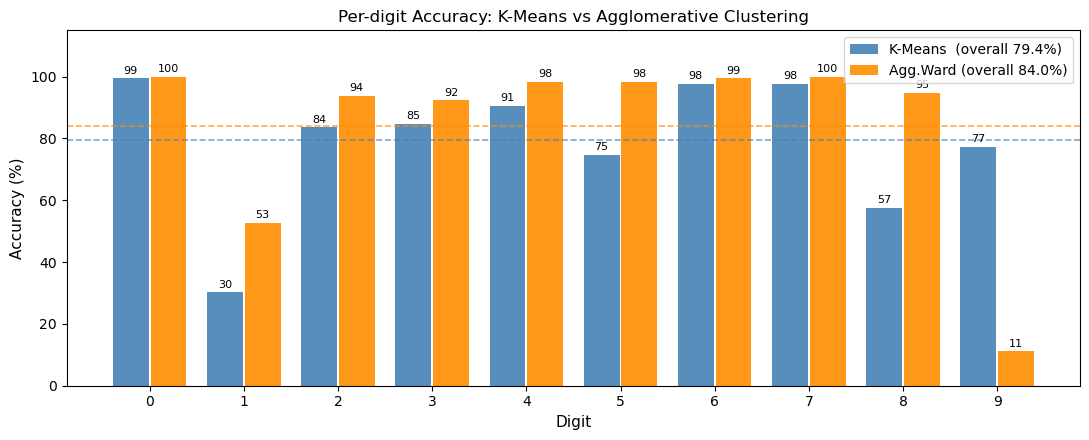

In [17]:
# Per-digit accuracy bar chart
x = np.arange(10)
fig, ax = plt.subplots(figsize=(11, 4.5))

bars1 = ax.bar(x - 0.2, [v*100 for v in km_per],  0.38,
               label=f'K-Means  (overall {km_acc*100:.1f}%)',  color='steelblue', alpha=0.9)
bars2 = ax.bar(x + 0.2, [v*100 for v in agg_per], 0.38,
               label=f'Agg.Ward (overall {agg_acc*100:.1f}%)', color='darkorange', alpha=0.9)

ax.axhline(km_acc*100,  color='steelblue',  linestyle='--', linewidth=1.2, alpha=0.7)
ax.axhline(agg_acc*100, color='darkorange', linestyle='--', linewidth=1.2, alpha=0.7)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{bar.get_height():.0f}', ha='center', fontsize=8)

ax.set_xlabel('Digit', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-digit Accuracy: K-Means vs Agglomerative Clustering', fontsize=12)
ax.set_xticks(x)
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Confusion Matrices

This way we can apply the mapping to all clusters and compute accuracy through a confusion matrix. 

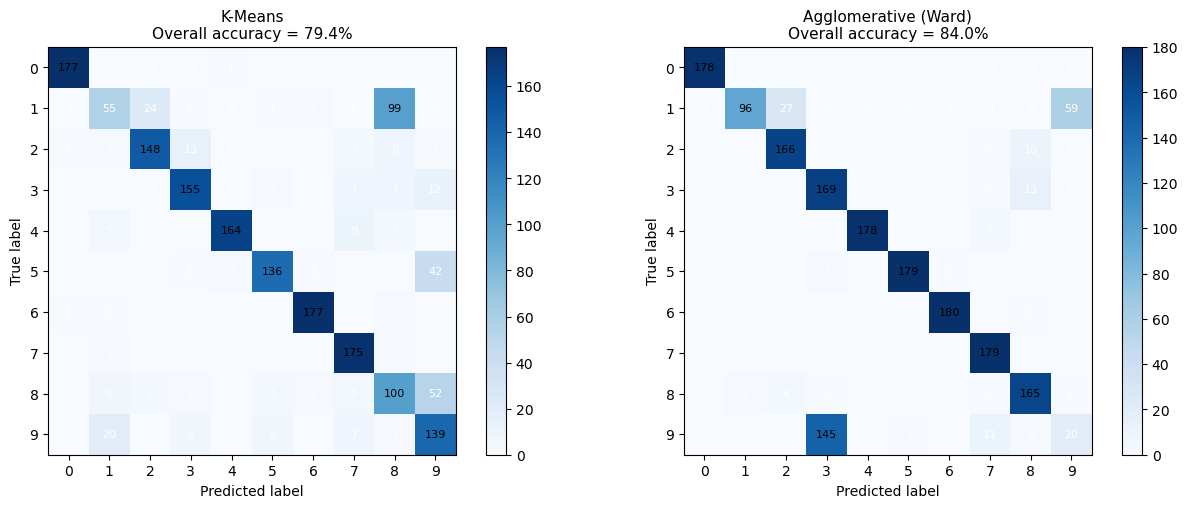

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, aligned, title, acc in zip(
        axes,
        [km_aligned, agg_aligned],
        ['K-Means', 'Agglomerative (Ward)'],
        [km_acc, agg_acc]):

    cm_mat = confusion_matrix(y, aligned)
    im     = ax.imshow(cm_mat, interpolation='nearest', cmap='Blues')
    fig.colorbar(im, ax=ax)

    ax.set_title(f'{title}\nOverall accuracy = {acc*100:.1f}%', fontsize=11)
    ax.set_xlabel('Predicted label', fontsize=10)
    ax.set_ylabel('True label',      fontsize=10)
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))

    thresh = cm_mat.max() / 2
    for i in range(10):
        for j in range(10):
            ax.text(j, i, str(cm_mat[i, j]),
                    ha='center', va='center', fontsize=8,
                    color='white' if cm_mat[i, j] < thresh else 'black')

plt.tight_layout()
plt.show()

## 8. PCA 2D Visualisation

Variance explained by PC1+PC2 : 28.5%


/var/folders/l6/h7clp4vx5dd4pfgsnhs_l58h0000gn/T/ipykernel_23778/2541212954.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


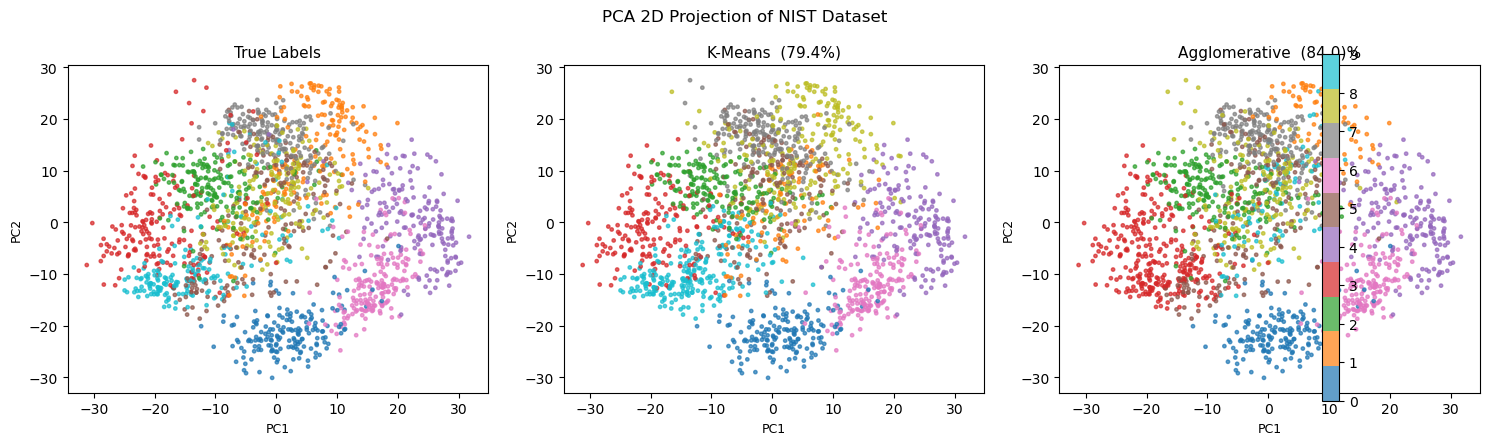

In [19]:
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)
print(f'Variance explained by PC1+PC2 : {pca.explained_variance_ratio_.sum()*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, lbls, title in zip(
        axes,
        [y, km_aligned, agg_aligned],
        ['True Labels', f'K-Means  ({km_acc*100:.1f}%)', f'Agglomerative  ({agg_acc*100:.1f})%']):

    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                    c=lbls, cmap='tab10', vmin=0, vmax=9,
                    s=6, alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)

fig.colorbar(sc, ax=axes, orientation='vertical',
             fraction=0.02, pad=0.02, ticks=range(10))
fig.suptitle('PCA 2D Projection of NIST Dataset', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Examples

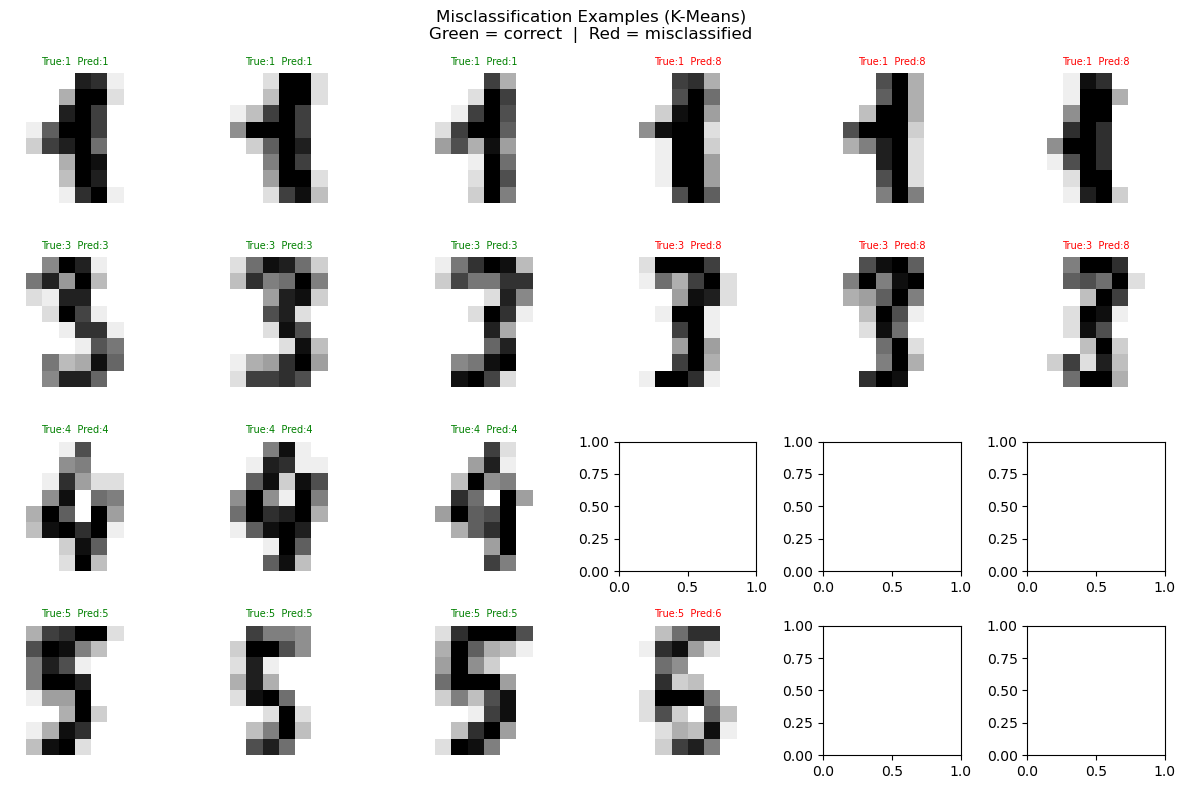

In [23]:
confused_pairs = [(1, 8), (3, 8), (4, 9), (5, 6)]

fig, axes = plt.subplots(len(confused_pairs), 6,
                         figsize=(12, 8))
fig.suptitle('Misclassification Examples (K-Means)\n'
             'Green = correct  |  Red = misclassified', fontsize=12)

for row, (true_d, pred_d) in enumerate(confused_pairs):
    correct = np.where((y == true_d) & (km_aligned == true_d))[0][:3]
    wrong   = np.where((y == true_d) & (km_aligned == pred_d))[0][:3]
    samples = list(correct) + list(wrong)
    colors_ = ['green']*3 + ['red']*3

    for col, (idx, c) in enumerate(zip(samples, colors_)):
        ax = axes[row, col]
        ax.imshow(images[idx], cmap='gray_r', interpolation='nearest')
        ax.set_title(f'True:{y[idx]}  Pred:{km_aligned[idx]}',
                     color=c, fontsize=7)
        ax.axis('off')

    axes[row, 0].set_ylabel(f'True {true_d}\nvs pred {pred_d}',
                            fontsize=9, labelpad=4)

plt.tight_layout()
plt.show()

## 10. Summary

### Key findings
- **Digit 0** is easiest for both methods — its closed circular shape forms a tight, isolated cluster.
- **Digit 1** is hardest for K-Means (30%) — the narrow vertical stroke overlaps with '7' and '8' in pixel space.
- **Agglomerative Ward** outperforms K-Means overall because it is not sensitive to random initialisation.
- The **Hungarian algorithm** is essential: raw cluster IDs are arbitrary and cannot be directly compared to digit labels.
- Main confusion pairs: **1↔8**, **3↔8**, **4↔9**, **5↔6** — all visually similar digit pairs.